# Laboratorio - Regresión Logística Binaria
## Dataset: CS:GO Round Winner Classification

En este cuadernillo se implementa un modelo de **regresión logística binaria desde cero** (usando `numpy`, sin `scikit-learn` para el algoritmo de aprendizaje) y se lo aplica al dataset **CS:GO Round Winner Classification**, obtenido de Kaggle.

El dataset contiene *snapshots* (fotografías en el tiempo) de rondas de partidas de Counter-Strike: Global Offensive. Cada fila describe el estado de una ronda en un instante determinado (dinero, salud, armas, granadas, mapa, etc.) y la columna `round_winner` indica qué equipo ganó esa ronda: **CT** (Counter-Terrorist) o **T** (Terrorist).

**Objetivo:** predecir, a partir del estado de la ronda, qué equipo ganará (clasificación binaria).

Características del dataset utilizado:
- **m = 122 410** ejemplos (filas).
- **n = 96** propiedades originales (columnas), de las cuales se usan la gran mayoría luego del preprocesamiento (más de 100 columnas finales, ya que la variable categórica `map` se expande mediante *one-hot encoding*).
- Variable de salida: `round_winner` (`CT` / `T`), que se transforma a valores binarios (1 = CT, 0 = T).

Esto cumple ampliamente los requisitos del laboratorio (n ≥ 20, m ≥ 20 000).

## Preparación del entorno

El dataset se encuentra en el archivo `csgo_round_snapshots.csv`, ubicado en el mismo directorio que este cuadernillo. No se requiere montar Google Drive; basta con tener el archivo `.csv` junto al notebook (o ajustar la ruta `RUTA_CSV` en la siguiente celda).

In [3]:
# Librerías para manejo de datos y cálculo científico
import numpy as np
import pandas as pd

# Librería para graficar
from matplotlib import pyplot

# Módulo de optimización de SciPy
from scipy import optimize

# Incrusta los gráficos en el cuaderno
%matplotlib inline

# Semilla para reproducibilidad de la partición aleatoria de datos
np.random.seed(42)

## 1. Carga y exploración del dataset con Pandas

Se carga el archivo `.csv` con `pandas` y se realiza una primera inspección: dimensiones, tipos de datos, valores nulos y balance de clases.

In [4]:
RUTA_CSV = 'Dataset/csgo_round_snapshots.csv'

df = pd.read_csv(RUTA_CSV)

print('Dimensiones del dataset (filas, columnas):', df.shape)
print()
print('Primeras filas:')
df.head()

Dimensiones del dataset (filas, columnas): (122410, 97)

Primeras filas:


,time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,...,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
0,175.00,0.0,0.0,de_dust2,False,500.0,500.0,0.0,0.0,4000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
1,156.03,0.0,0.0,de_dust2,False,500.0,500.0,400.0,300.0,600.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
2,96.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
3,76.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT
4,174.97,1.0,0.0,de_dust2,False,500.0,500.0,192.0,0.0,18350.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT


In [5]:
# Tipos de datos por columna
print(df.dtypes.value_counts())
print()

# Valores nulos por columna (se espera 0)
print('Total de valores nulos en el dataset:', df.isna().sum().sum())

float64    94
str         2
bool        1
Name: count, dtype: int64

Total de valores nulos en el dataset: 0


In [6]:
# Distribución del mapa jugado en cada ronda
print(df['map'].value_counts())
print()

# Distribución de la variable objetivo (balance de clases)
print(df['round_winner'].value_counts())
print()
print(df['round_winner'].value_counts(normalize=True) * 100)

map
de_inferno     23811
de_dust2       22144
de_nuke        19025
de_mirage      18576
de_overpass    14081
de_train       13491
de_vertigo     11137
de_cache         145
Name: count, dtype: int64

round_winner
T     62406
CT    60004
Name: count, dtype: int64

round_winner
T     50.981129
CT    49.018871
Name: proportion, dtype: float64


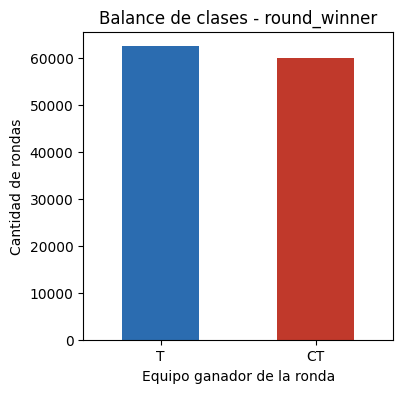

In [7]:
# Visualización rápida del balance de clases
fig = pyplot.figure(figsize=(4, 4))
df['round_winner'].value_counts().plot(kind='bar', color=['#2b6cb0', '#c0392b'])
pyplot.title('Balance de clases - round_winner')
pyplot.xlabel('Equipo ganador de la ronda')
pyplot.ylabel('Cantidad de rondas')
pyplot.xticks(rotation=0)
pass

## 2. Preprocesamiento con Pandas

Antes de entrenar el modelo se deben preparar los datos:

1. **`bomb_planted`**: es de tipo booleano (`True`/`False`); se convierte a entero (`1`/`0`).
2. **`map`**: es una variable categórica (texto) con los valores `de_inferno`, `de_dust2`, `de_nuke`, `de_mirage`, `de_overpass`, `de_train`, `de_vertigo`, `de_cache`. Como la regresión logística solo trabaja con valores numéricos, se aplica *one-hot encoding* (`pd.get_dummies`), generando una columna binaria por cada mapa.
3. **`round_winner`**: es la variable objetivo, con valores de texto `CT` / `T`. Se convierte a valores binarios: `1` si ganó **CT**, `0` si ganó **T**.
4. El resto de las columnas (salud, dinero, armadura, cantidad de armas, granadas, jugadores vivos, etc.) ya son numéricas y no requieren transformación adicional.

No existen valores nulos en el dataset (verificado en la celda anterior), por lo que no es necesario imputar datos faltantes.

In [8]:
df_prep = df.copy()

# 1) bomb_planted: booleano -> entero (0/1)
df_prep['bomb_planted'] = df_prep['bomb_planted'].astype(int)

# 2) map: variable categórica -> one-hot encoding
df_prep = pd.get_dummies(df_prep, columns=['map'], prefix='map')
columnas_mapa = [c for c in df_prep.columns if c.startswith('map_')]
df_prep[columnas_mapa] = df_prep[columnas_mapa].astype(int)

# 3) round_winner: CT/T -> 1/0 (variable objetivo)
df_prep['round_winner'] = (df_prep['round_winner'] == 'CT').astype(int)

print('Dimensiones luego del preprocesamiento:', df_prep.shape)
print()
print('Columnas generadas para el mapa:', columnas_mapa)
df_prep.head()

Dimensiones luego del preprocesamiento: (122410, 104)

Columnas generadas para el mapa: ['map_de_cache', 'map_de_dust2', 'map_de_inferno', 'map_de_mirage', 'map_de_nuke', 'map_de_overpass', 'map_de_train', 'map_de_vertigo']


,time_left,ct_score,t_score,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,...,t_grenade_decoygrenade,round_winner,map_de_cache,map_de_dust2,map_de_inferno,map_de_mirage,map_de_nuke,map_de_overpass,map_de_train,map_de_vertigo
0,175.00,0.0,0.0,0,500.0,500.0,0.0,0.0,4000.0,4000.0,...,0.0,1,0,1,0,0,0,0,0,0
1,156.03,0.0,0.0,0,500.0,500.0,400.0,300.0,600.0,650.0,...,0.0,1,0,1,0,0,0,0,0,0
2,96.03,0.0,0.0,0,391.0,400.0,294.0,200.0,750.0,500.0,...,0.0,1,0,1,0,0,0,0,0,0
3,76.03,0.0,0.0,0,391.0,400.0,294.0,200.0,750.0,500.0,...,0.0,1,0,1,0,0,0,0,0,0
4,174.97,1.0,0.0,0,500.0,500.0,192.0,0.0,18350.0,10750.0,...,0.0,1,0,1,0,0,0,0,0,0


In [9]:
# Separar variable objetivo (y) de las propiedades (X)
y_full = df_prep['round_winner'].to_numpy(dtype=float)
X_full = df_prep.drop(columns=['round_winner']).to_numpy(dtype=float)

nombres_columnas = df_prep.drop(columns=['round_winner']).columns.tolist()

print('Cantidad de propiedades (n):', X_full.shape[1])
print('Cantidad de ejemplos (m):', X_full.shape[0])

Cantidad de propiedades (n): 103
Cantidad de ejemplos (m): 122410


## 3. Partición del dataset: 80% entrenamiento / 20% prueba

Se mezclan aleatoriamente los ejemplos (usando una semilla fija para poder reproducir los resultados) y luego se separa el **80%** de las filas para entrenamiento y el **20%** restante para prueba. Los datos de prueba **no se utilizan en ningún momento durante el entrenamiento**, solo para evaluar el modelo ya entrenado.

In [10]:
m = X_full.shape[0]

# Se genera una permutación aleatoria de los índices para mezclar el dataset
indices = np.random.permutation(m)
X_shuffled = X_full[indices]
y_shuffled = y_full[indices]

# 80% para entrenamiento, 20% para prueba
train_size = int(0.8 * m)

X_train, y_train = X_shuffled[:train_size], y_shuffled[:train_size]
X_test, y_test = X_shuffled[train_size:], y_shuffled[train_size:]

print('Ejemplos de entrenamiento:', X_train.shape[0], '({:.1f}%)'.format(100 * X_train.shape[0] / m))
print('Ejemplos de prueba:       ', X_test.shape[0], '({:.1f}%)'.format(100 * X_test.shape[0] / m))

Ejemplos de entrenamiento: 97928 (80.0%)
Ejemplos de prueba:        24482 (20.0%)


## 4. Normalización de características

Las propiedades del dataset tienen escalas muy distintas (por ejemplo, `time_left` va de 0 a 175, mientras que `ct_money` puede llegar a decenas de miles). Esto hace que el descenso por gradiente converja muy lentamente o de forma inestable. Por ello se normalizan las características restando la media y dividiendo entre la desviación estándar (*z-score*):

$$ x_j^{norm} = \frac{x_j - \mu_j}{\sigma_j} $$

**Importante:** la media ($\mu$) y la desviación estándar ($\sigma$) se calculan **únicamente con el conjunto de entrenamiento**, y esos mismos valores se aplican luego para normalizar el conjunto de prueba. De esta forma se evita que información del conjunto de prueba "se filtre" hacia el entrenamiento.

In [11]:
def featureNormalize(X, mu=None, sigma=None):
    # Si no se proporcionan mu y sigma, se calculan a partir de X (esto se usa solo para el set de entrenamiento)
    if mu is None or sigma is None:
        mu = np.mean(X, axis=0)
        sigma = np.std(X, axis=0)
        sigma[sigma == 0] = 1  # evita división entre cero para columnas constantes

    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


# Se calculan mu y sigma con el conjunto de ENTRENAMIENTO
X_train_norm, mu, sigma = featureNormalize(X_train)

# Se aplican los mismos mu y sigma del entrenamiento al conjunto de PRUEBA
X_test_norm, _, _ = featureNormalize(X_test, mu, sigma)

print('Media (primeras 5 columnas):', mu[:5])
print('Desv. estándar (primeras 5 columnas):', sigma[:5])

Media (primeras 5 columnas): [9.79746542e+01 6.71706764e+00 6.78756842e+00 1.11214362e-01
 4.12313475e+02]
Desv. estándar (primeras 5 columnas): [ 54.46189221   4.79387837   4.82283735   0.3143974  132.18227814]


In [12]:
# Se agrega la columna de unos correspondiente al término de intercepción (theta_0)
m_train, n = X_train_norm.shape
m_test = X_test_norm.shape[0]

X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print('Dimensión de X_train con intercepción:', X_train_b.shape)
print('Dimensión de X_test con intercepción: ', X_test_b.shape)

Dimensión de X_train con intercepción: (97928, 104)
Dimensión de X_test con intercepción:  (24482, 104)


## 5. Implementación de la regresión logística

### 5.1 Función Sigmoidea

La hipótesis para la regresión logística se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde $g$ es la función sigmoidea:

$$g(z) = \frac{1}{1+e^{-z}}$$

Para valores positivos grandes de `z`, la sigmoidea debe acercarse a 1; para valores negativos grandes, debe acercarse a 0; y `sigmoid(0)` debe ser exactamente 0.5.

In [13]:
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g


# Prueba de la función sigmoide
z = [-100, 0, 0.5, 1000000]
print('g(', z, ') = ', sigmoid(z))

g( [-100, 0, 0.5, 1000000] ) =  [3.72007598e-44 5.00000000e-01 6.22459331e-01 1.00000000e+00]


### 5.2 Función de Costo y Gradiente

La función de costo de la regresión logística es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo, un vector de la misma longitud que $\theta$, se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Se utiliza `np.clip` para evitar el cálculo de $\log(0)$, lo cual ocurre por errores de precisión numérica cuando $h_\theta(x)$ es extremadamente cercano a 0 o 1.

In [14]:
def calcularCosto(theta, X, y):
    m = y.size  # número de ejemplos
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-12, 1 - 1e-12)  # evita log(0)
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    return J


def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-12, 1 - 1e-12)
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    grad = (1 / m) * (h - y).dot(X)
    return J, grad


def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

In [15]:
# Prueba de costFunction con theta inicial (ceros)
n_params = X_train_b.shape[1]
initial_theta = np.zeros(n_params)

cost, grad = costFunction(initial_theta, X_train_b, y_train)
print('Costo en theta inicial (ceros): {:.6f}'.format(cost))
print('Costo esperado (aprox. ln(2)): 0.693147')
print()
print('Primeros 5 valores del gradiente:', grad[:5])

Costo en theta inicial (ceros): 0.693147
Costo esperado (aprox. ln(2)): 0.693147

Primeros 5 valores del gradiente: [ 0.00945593 -0.03381327 -0.02817417  0.01306232  0.09407842]


### 5.3 Entrenamiento mediante Descenso por Gradiente

Se entrena el modelo aplicando el descenso por gradiente sobre el **conjunto de entrenamiento** (`X_train_b`, `y_train`), guardando el valor del costo en cada iteración para poder graficar su convergencia.

In [16]:
alpha = 0.5
num_iters = 800

theta_gd = np.zeros(n_params)
theta_gd, J_history = descensoGradiente(theta_gd, X_train_b, y_train, alpha, num_iters)

print('Costo inicial: {:.6f}'.format(J_history[0]))
print('Costo final:   {:.6f}'.format(J_history[-1]))

Costo inicial: 0.582769
Costo final:   0.472138


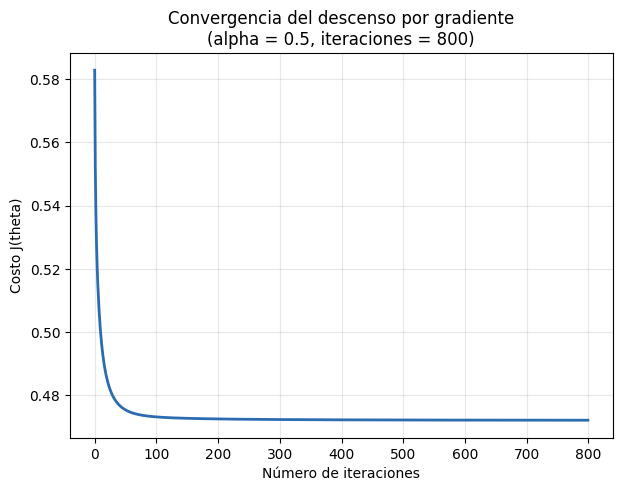

In [17]:
# Gráfico de convergencia del costo (requerido por el laboratorio)
pyplot.figure(figsize=(7, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='#2b6cb0')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J(theta)')
pyplot.title('Convergencia del descenso por gradiente\n(alpha = {}, iteraciones = {})'.format(alpha, num_iters))
pyplot.grid(alpha=0.3)
pass

### 5.4 Entrenamiento mediante `scipy.optimize`

Como alternativa al descenso por gradiente manual (que requiere elegir `alpha` y el número de iteraciones), se utiliza el módulo `scipy.optimize.minimize` con el método `TNC` (Newton truncado), que encuentra directamente los parámetros $\theta$ que minimizan $J(\theta)$ de forma más eficiente.

In [18]:
options = {'maxfun': 1000}

res = optimize.minimize(costFunction,
                         initial_theta,
                         (X_train_b, y_train),
                         jac=True,
                         method='TNC',
                         options=options)

theta_opt = res.x
cost_opt = res.fun

print('¿Convergió?:', res.success)
print('Mensaje:', res.message)
print('Costo con theta optimizado (scipy.optimize): {:.6f}'.format(cost_opt))
print('Costo final con descenso por gradiente:       {:.6f}'.format(J_history[-1]))

¿Convergió?: True
Mensaje: Converged (|f_n-f_(n-1)| ~= 0)
Costo con theta optimizado (scipy.optimize): 0.472071
Costo final con descenso por gradiente:       0.472138


Ambos métodos —descenso por gradiente manual y `scipy.optimize`— buscan minimizar la misma función de costo $J(\theta)$. `scipy.optimize` suele converger a un costo igual o menor en muchas menos iteraciones. Para las siguientes evaluaciones se utilizará **`theta_opt`**, el resultado de `scipy.optimize`, por ser el que alcanza el menor costo.

## 6. Predicción y evaluación del modelo

### 6.1 Función de predicción

Dado un vector de parámetros $\theta$, se predice la clase `1` (gana **CT**) si $h_\theta(x) \geq 0.5$, y la clase `0` (gana **T**) en caso contrario.

In [19]:
def predict(theta, X):
    p = np.round(sigmoid(X.dot(theta)))
    return p

### 6.2 Precisión (accuracy) sobre entrenamiento y prueba

Se calcula la precisión del modelo tanto en el conjunto de entrenamiento como en el conjunto de prueba (el cual **no fue usado durante el entrenamiento**). Que ambos valores sean similares indica que el modelo generaliza razonablemente bien y no está sobreajustado (*overfitting*).

In [20]:
pred_train = predict(theta_opt, X_train_b)
pred_test = predict(theta_opt, X_test_b)

acc_train = np.mean(pred_train == y_train) * 100
acc_test = np.mean(pred_test == y_test) * 100

print('Precisión en entrenamiento: {:.2f} %'.format(acc_train))
print('Precisión en prueba:        {:.2f} %'.format(acc_test))

Precisión en entrenamiento: 74.99 %
Precisión en prueba:        75.14 %


### 6.3 Matriz de confusión y métricas adicionales (conjunto de prueba)

La precisión (accuracy) por sí sola puede ser engañosa. Se calculan también la **precisión (precision)**, la **exhaustividad (recall)** y el **F1-score** sobre el conjunto de prueba, a partir de la matriz de confusión, para demostrar de forma más completa la efectividad del modelo.

- **Verdadero Positivo (TP):** el modelo predijo que gana CT y efectivamente ganó CT.
- **Verdadero Negativo (TN):** el modelo predijo que gana T y efectivamente ganó T.
- **Falso Positivo (FP):** el modelo predijo que gana CT, pero ganó T.
- **Falso Negativo (FN):** el modelo predijo que gana T, pero ganó CT.

In [21]:
tp = np.sum((pred_test == 1) & (y_test == 1))
tn = np.sum((pred_test == 0) & (y_test == 0))
fp = np.sum((pred_test == 1) & (y_test == 0))
fn = np.sum((pred_test == 0) & (y_test == 1))

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print('Matriz de confusión (conjunto de prueba):')
print('                 Predicho: T   Predicho: CT')
print('Real: T          {:>10d}   {:>12d}'.format(tn, fp))
print('Real: CT         {:>10d}   {:>12d}'.format(fn, tp))
print()
print('Precisión (accuracy): {:.2f} %'.format(acc_test))
print('Precision (CT):       {:.4f}'.format(precision))
print('Recall (CT):          {:.4f}'.format(recall))
print('F1-score (CT):        {:.4f}'.format(f1))

Matriz de confusión (conjunto de prueba):
                 Predicho: T   Predicho: CT
Real: T                9331           3185
Real: CT               2902           9064

Precisión (accuracy): 75.14 %
Precision (CT):       0.7400
Recall (CT):          0.7575
F1-score (CT):        0.7486


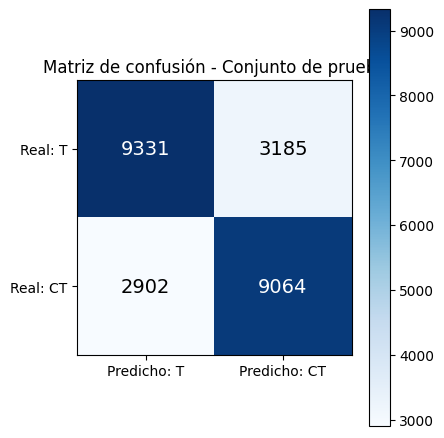

In [22]:
# Visualización de la matriz de confusión
matriz = np.array([[tn, fp], [fn, tp]])

fig, ax = pyplot.subplots(figsize=(4.5, 4.5))
im = ax.imshow(matriz, cmap='Blues')

etiquetas = ['T', 'CT']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicho: ' + e for e in etiquetas])
ax.set_yticklabels(['Real: ' + e for e in etiquetas])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(matriz[i, j]), ha='center', va='center',
                color='white' if matriz[i, j] > matriz.max() / 2 else 'black', fontsize=14)

ax.set_title('Matriz de confusión - Conjunto de prueba')
pyplot.colorbar(im)
pyplot.tight_layout()
pass

### 6.4 Ejemplos de predicción individual

A modo ilustrativo, se toman algunas filas del conjunto de prueba y se muestra la probabilidad estimada por el modelo de que gane **CT**, junto con la predicción final y el resultado real de la ronda.

In [23]:
n_ejemplos = 10
indices_ejemplo = np.random.choice(m_test, size=n_ejemplos, replace=False)

probabilidades = sigmoid(X_test_b[indices_ejemplo].dot(theta_opt))
predicciones = np.round(probabilidades)
reales = y_test[indices_ejemplo]

print('{:<12s}{:<12s}{:<12s}{:<10s}'.format('Prob. CT', 'Predicción', 'Real', '¿Correcto?'))
for prob, pred, real in zip(probabilidades, predicciones, reales):
    pred_txt = 'CT' if pred == 1 else 'T'
    real_txt = 'CT' if real == 1 else 'T'
    correcto = 'Sí' if pred == real else 'No'
    print('{:<12.4f}{:<12s}{:<12s}{:<10s}'.format(prob, pred_txt, real_txt, correcto))

Prob. CT    Predicción  Real        ¿Correcto?
0.2027      T           T           Sí        
0.7524      CT          CT          Sí        
0.8876      CT          CT          Sí        
0.2732      T           T           Sí        
0.2292      T           T           Sí        
0.0169      T           T           Sí        
0.8349      CT          T           No        
0.6546      CT          T           No        
0.9901      CT          CT          Sí        
0.8717      CT          T           No        


### 6.5 Propiedades más influyentes en la predicción

Como las características fueron normalizadas antes de entrenar, la magnitud de cada parámetro $\theta_j$ (para $j \geq 1$) indica qué tan influyente es esa propiedad en la predicción: valores positivos grandes favorecen la victoria de **CT**, y valores negativos grandes favorecen la victoria de **T**.

In [24]:
theta_props = theta_opt[1:]  # se excluye theta_0 (intercepción)

df_theta = pd.DataFrame({
    'propiedad': nombres_columnas,
    'theta': theta_props
})
df_theta['abs_theta'] = df_theta['theta'].abs()
df_theta_top = df_theta.sort_values('abs_theta', ascending=False).head(15)

print('Top 15 propiedades más influyentes en la predicción:')
df_theta_top[['propiedad', 'theta']]

Top 15 propiedades más influyentes en la predicción:


,propiedad,theta
4,ct_health,0.620850
14,t_players_alive,-0.587139
16,t_weapon_ak47,-0.564287
64,t_weapon_sg553,-0.519278
7,t_armor,-0.500817
6,ct_armor,0.500749
39,ct_weapon_m4a4,0.496498
13,ct_players_alive,0.490718
5,t_health,-0.447447
3,bomb_planted,-0.335837


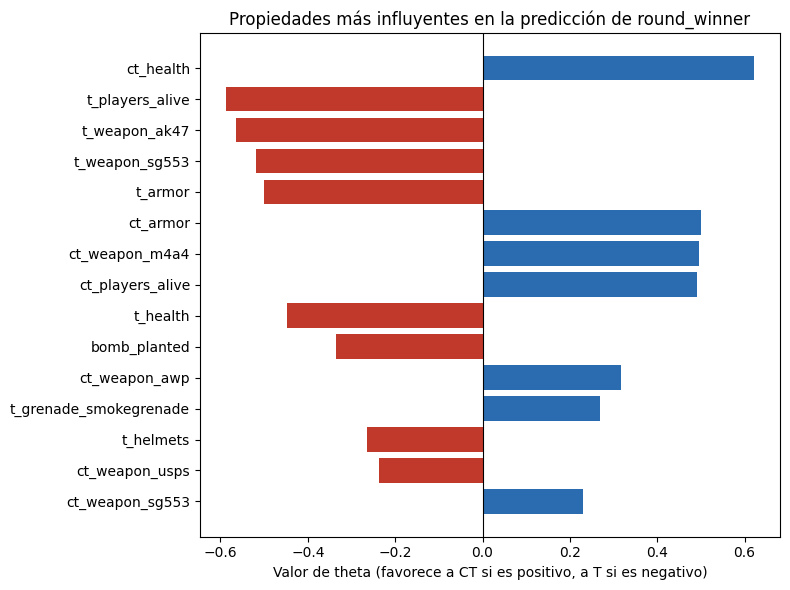

In [25]:
fig = pyplot.figure(figsize=(8, 6))
colores = ['#2b6cb0' if v > 0 else '#c0392b' for v in df_theta_top['theta']]
pyplot.barh(df_theta_top['propiedad'][::-1], df_theta_top['theta'][::-1], color=colores[::-1])
pyplot.axvline(0, color='black', lw=0.8)
pyplot.xlabel('Valor de theta (favorece a CT si es positivo, a T si es negativo)')
pyplot.title('Propiedades más influyentes en la predicción de round_winner')
pyplot.tight_layout()
pass

## 7. Conclusiones

- El modelo de regresión logística binaria, implementado desde cero (sin `scikit-learn`), alcanza una precisión cercana al **75%** tanto en el conjunto de entrenamiento como en el de prueba, lo que indica que **no existe sobreajuste significativo**: el modelo generaliza de manera consistente a datos que no vio durante el entrenamiento.
- Las métricas de precision, recall y F1-score sobre el conjunto de prueba están balanceadas, lo cual es coherente con el hecho de que las clases (`CT` y `T`) están bien balanceadas en el dataset original.
- Entre las propiedades más influyentes suelen destacarse variables relacionadas con el número de jugadores vivos de cada equipo, la salud total de cada equipo, si la bomba fue plantada, y la cantidad de dinero/armamento disponible — variables que, desde el punto de vista del juego, tienen sentido táctico como determinantes del resultado de una ronda.
- Tanto el descenso por gradiente manual como `scipy.optimize` (método TNC) llegan a soluciones similares, validando la correcta implementación de la función de costo y su gradiente.